# Analisis data polutan untuk mengetahui sumber polutan dan kualitas udara di daerah Bangkalan.

## 1. Business Understanding

### Tujuan

Proyek ini bertujuan untuk mengetahui dan menganalisis kondisi kualitas udara di wilayah **Kabupaten Bangkalan, Jawa Timur** berdasarkan data beberapa polutan atmosfer. Polutan yang dianalisis meliputi **CO, NO₂, HCHO, O₃, SO₂, dan CH₄**.

Data dikumpulkan menggunakan data satelit **Sentinel-5P** melalui platform Copernicus Data Space Ecosystem. Wilayah pengambilan data dibatasi menggunakan koordinat geografis yang membentuk area penelitian Kabupaten Bangkalan.

Data yang diperoleh kemudian diolah menjadi data harian dan disimpan dalam format **CSV** untuk selanjutnya dianalisis dan divisualisasikan dalam bentuk **grafik time series**.

### Manfaat

Analisis ini bermanfaat untuk memberikan gambaran mengenai kondisi dan perubahan konsentrasi polutan udara di Kabupaten Bangkalan selama periode pengamatan. Selain itu, hasil analisis dapat digunakan untuk:

* mengetahui pola perubahan konsentrasi polutan dari waktu ke waktu;
* mengetahui polutan yang memiliki nilai relatif tinggi atau rendah;
* mengidentifikasi adanya nilai yang tidak biasa atau **outlier** pada data;
* memberikan gambaran awal mengenai kemungkinan sumber polutan berdasarkan karakteristik masing-masing polutan; dan
* menjadi informasi pendukung untuk memahami kondisi lingkungan dan kualitas udara di wilayah Kabupaten Bangkalan.

### Wilayah dan Periode Penelitian

Wilayah penelitian dibatasi pada area **Kabupaten Bangkalan, Jawa Timur** menggunakan polygon berdasarkan titik koordinat geografis.

Periode data yang digunakan adalah **31 Agustus 2025 sampai 31 Agustus 2026**, sehingga data mencakup sekurang-kurangnya satu tahun sampai dengan tanggal 31 Agustus 2026 sesuai dengan ketentuan tugas.


## 2. AOI menggunakan koordinat

Pada tahap ini ditentukan **Area of Interest (AOI)** atau wilayah yang menjadi objek penelitian. AOI digunakan untuk membatasi data satelit agar data yang diambil hanya berasal dari wilayah penelitian, yaitu **Kabupaten Bangkalan**.

Batas wilayah dibuat dalam bentuk **Polygon GeoJSON** yang terdiri dari beberapa titik koordinat longitude dan latitude. Setiap titik koordinat saling terhubung sehingga membentuk area penelitian.

Penggunaan AOI penting dalam proses crawling/pengambilan data karena data Sentinel-5P memiliki cakupan wilayah yang luas. Dengan adanya AOI, data yang dianalisis dapat difokuskan pada wilayah Kabupaten Bangkalan.


In [10]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.7096307, -7.0398682],
            [112.7211862, -7.0392129],
            [112.7429764, -7.0208632],
            [112.7690587, -7.0008743],
            [112.8273426, -6.9302456],
            [112.8835275, -6.9640896],
            [112.9276856, -6.9883133],
            [112.9971103, -7.0536224],
            [113.0031473, -7.0991547],
            [113.0563957, -7.1225576],
            [113.0553863, -7.1671046],
            [113.0724605, -7.1927095],
            [113.0632787, -7.2158838],
            [112.9879140, -7.2044249],
            [112.8172278, -7.1614931],
            [112.7170484, -7.1759788],
            [112.6913203, -7.1549554],
            [112.7015631, -7.0930380],
            [112.6851976, -7.0948119],
            [112.6723173, -7.0676726],
            [112.6838026, -7.0307433],
            [112.7077916, -7.0404372],
            [112.7086592, -7.0440856],
            [112.7096307, -7.0398682]
        ]
    ]
}

## 3. Periode data

Pada tahap ini menentukan periode pengambilan data. Data dimulai pada 31 Agustus 2025 dan menggunakan 1 September 2026 sebagai batas akhir agar tanggal 31 Agustus 2026 dapat termasuk dalam rentang pengambilan data.


In [11]:
temporal_extent=["2025-08-31", "2026-09-01"] #disini sampai 2026-09-01 supaya berenti di 2026-09-01

In [12]:
!pip install openeo

In [13]:
import openeo

connection = openeo.connect(
    "https://openeo.dataspace.copernicus.eu"
)

connection.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

## 4. CO

**Karbon Monoksida (CO)** merupakan salah satu polutan udara yang berkaitan dengan proses pembakaran tidak sempurna. CO dapat berasal dari aktivitas kendaraan bermotor, pembakaran bahan bakar, kegiatan industri, maupun pembakaran terbuka.

Pada tahap ini diambil data CO dari **Sentinel-5P** untuk wilayah Kabupaten Bangkalan selama periode 31 Agustus 2025–31 Agustus 2026.

Data kemudian dilakukan dua proses agregasi, yaitu:

1. **Agregasi temporal harian**, untuk mendapatkan nilai rata-rata CO setiap hari.
2. **Agregasi spasial**, untuk mendapatkan nilai rata-rata CO pada wilayah AOI Kabupaten Bangkalan.

Hasil pengambilan data kemudian disimpan dalam file **CO.nc** untuk tahap pengolahan selanjutnya.


In [14]:
!pip install netCDF4

import netCDF4
import pandas as pd
import numpy as np

In [15]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["CO"],
)

# Agregasi harian
s5p_co_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_co_aoi = s5p_co_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

# Simpan hasil data
job = s5p_co_aoi.execute_batch(
    title="CO",
    outputfile="CO.nc"
)

# Menjalankan proses sampai selesai
job.start_and_wait()

# =====================================================
# CEK DATA YANG BERHASIL DISIMPAN
# =====================================================

import netCDF4

ds = netCDF4.Dataset("CO.nc")

# Ambil variabel waktu
time_var = ds.variables["t"]

# Konversi waktu NetCDF menjadi tanggal
dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

print("DATA CO BERHASIL DISIMPAN")
print("Tanggal awal  :", dates[0])
print("Tanggal akhir :", dates[-1])
print("Jumlah data   :", len(dates))

ds.close()

0:00:00 Job 'j-2608301355044961bb619cfb38c4a9b2': send 'start'
0:00:03 Job 'j-2608301355044961bb619cfb38c4a9b2': queued (progress 0%)
0:00:08 Job 'j-2608301355044961bb619cfb38c4a9b2': queued (progress 0%)
0:00:14 Job 'j-2608301355044961bb619cfb38c4a9b2': queued (progress 0%)
0:00:22 Job 'j-2608301355044961bb619cfb38c4a9b2': queued (progress 0%)
0:00:32 Job 'j-2608301355044961bb619cfb38c4a9b2': queued (progress 0%)
0:00:45 Job 'j-2608301355044961bb619cfb38c4a9b2': queued (progress 0%)
0:01:00 Job 'j-2608301355044961bb619cfb38c4a9b2': queued (progress 0%)
0:01:19 Job 'j-2608301355044961bb619cfb38c4a9b2': running (progress N/A)
0:01:44 Job 'j-2608301355044961bb619cfb38c4a9b2': running (progress N/A)
0:02:14 Job 'j-2608301355044961bb619cfb38c4a9b2': running (progress N/A)
0:02:51 Job 'j-2608301355044961bb619cfb38c4a9b2': running (progress N/A)
0:03:38 Job 'j-2608301355044961bb619cfb38c4a9b2': finished (progress 100%)
0:00:00 Job 'j-2608301355044961bb619cfb38c4a9b2': send 'start'
0:00:01 Jo

## 5. NO₂

**Nitrogen Dioksida (NO₂)** merupakan salah satu polutan udara yang banyak berkaitan dengan aktivitas pembakaran bahan bakar. Sumber NO₂ dapat berasal dari kendaraan bermotor, kegiatan industri, pembangkit listrik, dan proses pembakaran lainnya.

Data NO₂ diambil dari Sentinel-5P dengan batas wilayah Kabupaten Bangkalan dan periode pengamatan satu tahun.

Data kemudian diagregasi secara harian dan spasial sehingga diperoleh nilai rata-rata NO₂ pada wilayah penelitian untuk setiap waktu pengamatan. Hasilnya disimpan dalam file **NO2.nc**.


In [16]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["NO2"],
)

# Agregasi harian
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5post.execute_batch(
    title="NO2",
    outputfile="NO2.nc"
)

import netCDF4

# Buka file hasil crawling
ds = netCDF4.Dataset("NO2.nc")

# Cek variabel yang tersedia
print("Variabel dalam file:")
print(list(ds.variables.keys()))

# Ambil variabel waktu
time_var = ds.variables["t"]

# Konversi waktu NetCDF menjadi tanggal
dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

# Hasil pengecekan
print("HASIL PENGECEKAN DATA NO2")
print("Tanggal pertama :", dates[0])
print("Tanggal terakhir:", dates[-1])
print("Jumlah data     :", len(dates))

ds.close()

0:00:00 Job 'j-260830135849419096e3838d54caf019': send 'start'
0:00:02 Job 'j-260830135849419096e3838d54caf019': created (progress 0%)
0:00:08 Job 'j-260830135849419096e3838d54caf019': queued (progress 0%)
0:00:14 Job 'j-260830135849419096e3838d54caf019': queued (progress 0%)
0:00:22 Job 'j-260830135849419096e3838d54caf019': queued (progress 0%)
0:00:32 Job 'j-260830135849419096e3838d54caf019': running (progress N/A)
0:00:44 Job 'j-260830135849419096e3838d54caf019': running (progress N/A)
0:01:00 Job 'j-260830135849419096e3838d54caf019': running (progress N/A)
0:01:19 Job 'j-260830135849419096e3838d54caf019': running (progress N/A)
0:01:43 Job 'j-260830135849419096e3838d54caf019': running (progress N/A)
0:02:13 Job 'j-260830135849419096e3838d54caf019': running (progress N/A)
0:02:51 Job 'j-260830135849419096e3838d54caf019': finished (progress 100%)
Variabel dalam file:
['t', 'x', 'y', 'crs', 'NO2']

HASIL PENGECEKAN DATA NO2
Tanggal pertama : 2025-08-31 00:00:00
Tanggal terakhir: 2026-

## 6. HCHO

**HCHO (Formaldehida)** merupakan senyawa yang dapat ditemukan di atmosfer dan dapat berasal dari berbagai proses pembakaran maupun aktivitas manusia.

Pada tahap ini dilakukan pengambilan data HCHO dari Sentinel-5P pada wilayah Kabupaten Bangkalan. Data dibatasi berdasarkan AOI dan periode 31 Agustus 2025 sampai 31 Agustus 2026.

Data kemudian diagregasi secara temporal menjadi data harian dan secara spasial berdasarkan wilayah penelitian. Hasil pengambilan data disimpan dalam file **HCHO.nc**.


In [17]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["HCHO"],
)

# Agregasi harian
s5p_hcho_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_hcho_aoi = s5p_hcho_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5post.execute_batch(
    title="HCHO",
    outputfile="HCHO.nc"
)


import netCDF4

ds = netCDF4.Dataset("HCHO.nc")

# Ambil variabel waktu
time_var = ds.variables["t"]

# Konversi waktu menjadi tanggal
dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

print("HASIL PENGECEKAN DATA HCHO")
print("Tanggal pertama :", dates[0])
print("Tanggal terakhir:", dates[-1])
print("Jumlah data     :", len(dates))

ds.close()

0:00:00 Job 'j-260830140146430fb25210becd1472eb': send 'start'
0:00:03 Job 'j-260830140146430fb25210becd1472eb': queued (progress 0%)
0:00:08 Job 'j-260830140146430fb25210becd1472eb': queued (progress 0%)
0:00:15 Job 'j-260830140146430fb25210becd1472eb': queued (progress 0%)
0:00:23 Job 'j-260830140146430fb25210becd1472eb': queued (progress 0%)
0:00:33 Job 'j-260830140146430fb25210becd1472eb': running (progress N/A)
0:00:45 Job 'j-260830140146430fb25210becd1472eb': running (progress N/A)
0:01:01 Job 'j-260830140146430fb25210becd1472eb': running (progress N/A)
0:01:20 Job 'j-260830140146430fb25210becd1472eb': running (progress N/A)
0:01:44 Job 'j-260830140146430fb25210becd1472eb': running (progress N/A)
0:02:14 Job 'j-260830140146430fb25210becd1472eb': running (progress N/A)
0:02:52 Job 'j-260830140146430fb25210becd1472eb': running (progress N/A)
0:03:39 Job 'j-260830140146430fb25210becd1472eb': finished (progress 100%)
HASIL PENGECEKAN DATA HCHO
Tanggal pertama : 2025-08-31 00:00:00
Ta

## 7. O₃

**Ozon (O₃)** merupakan polutan sekunder yang terbentuk melalui reaksi kimia di atmosfer dengan bantuan sinar matahari. Pembentukan O₃ berkaitan dengan keberadaan prekursor seperti nitrogen oksida (NOx) dan senyawa organik volatil (VOC).

Data O₃ diperoleh dari Sentinel-5P untuk wilayah Kabupaten Bangkalan selama periode penelitian.

Sama seperti polutan lainnya, data O₃ diagregasi berdasarkan waktu dan wilayah sehingga dapat digunakan untuk melihat perubahan konsentrasi O₃ dari hari ke hari. Data hasil pengambilan disimpan dalam file **O3.nc**.


In [18]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["O3"],
)

# Agregasi harian
s5p_o3_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_o3_aoi = s5post.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5post.execute_batch(
    title="O3",
    outputfile="O3.nc"
)


import netCDF4

ds = netCDF4.Dataset("O3.nc")

# Ambil variabel waktu
time_var = ds.variables["t"]

# Konversi waktu menjadi tanggal
dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

print("HASIL PENGECEKAN DATA O3")
print("Tanggal pertama :", dates[0])
print("Tanggal terakhir:", dates[-1])
print("Jumlah data     :", len(dates))

ds.close()

0:00:00 Job 'j-26083014053040a29980e827a2b6bdbf': send 'start'
0:00:03 Job 'j-26083014053040a29980e827a2b6bdbf': queued (progress 0%)
0:00:08 Job 'j-26083014053040a29980e827a2b6bdbf': queued (progress 0%)
0:00:14 Job 'j-26083014053040a29980e827a2b6bdbf': queued (progress 0%)
0:00:22 Job 'j-26083014053040a29980e827a2b6bdbf': queued (progress 0%)
0:00:32 Job 'j-26083014053040a29980e827a2b6bdbf': queued (progress 0%)
0:00:45 Job 'j-26083014053040a29980e827a2b6bdbf': running (progress N/A)
0:01:00 Job 'j-26083014053040a29980e827a2b6bdbf': running (progress N/A)
0:01:19 Job 'j-26083014053040a29980e827a2b6bdbf': running (progress N/A)
0:01:43 Job 'j-26083014053040a29980e827a2b6bdbf': running (progress N/A)
0:02:14 Job 'j-26083014053040a29980e827a2b6bdbf': running (progress N/A)
0:02:51 Job 'j-26083014053040a29980e827a2b6bdbf': finished (progress 100%)
HASIL PENGECEKAN DATA O3
Tanggal pertama : 2025-08-31 00:00:00
Tanggal terakhir: 2026-08-30 00:00:00
Jumlah data     : 361


## 8. SO₂

**Sulfur Dioksida (SO₂)** merupakan gas pencemar yang terutama berkaitan dengan pembakaran bahan bakar yang mengandung sulfur. Sumber SO₂ dapat berasal dari kegiatan industri, pembangkit listrik, dan pembakaran bahan bakar fosil.

Data SO₂ diambil dari Sentinel-5P pada wilayah Kabupaten Bangkalan dengan periode pengamatan satu tahun.

Data kemudian diagregasi secara harian dan berdasarkan wilayah AOI. Hasil pengambilan data disimpan dalam file **SO2.nc**.


In [19]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["SO2"],
)

# Agregasi harian
s5p_so2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_so2_aoi = s5post.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5post.execute_batch(
    title="SO2",
    outputfile="SO2.nc"
)

import netCDF4

ds = netCDF4.Dataset("SO2.nc")

time_var = ds.variables["t"]

dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

print("HASIL PENGECEKAN DATA SO2")
print("Tanggal pertama :", dates[0])
print("Tanggal terakhir:", dates[-1])
print("Jumlah data     :", len(dates))

ds.close()

0:00:00 Job 'j-2608301408284e429963f568e6b44883': send 'start'
0:00:03 Job 'j-2608301408284e429963f568e6b44883': created (progress 0%)
0:00:09 Job 'j-2608301408284e429963f568e6b44883': queued (progress 0%)
0:00:15 Job 'j-2608301408284e429963f568e6b44883': queued (progress 0%)
0:00:23 Job 'j-2608301408284e429963f568e6b44883': queued (progress 0%)
0:00:33 Job 'j-2608301408284e429963f568e6b44883': queued (progress 0%)
0:00:46 Job 'j-2608301408284e429963f568e6b44883': running (progress N/A)
0:01:01 Job 'j-2608301408284e429963f568e6b44883': running (progress N/A)
0:01:20 Job 'j-2608301408284e429963f568e6b44883': running (progress N/A)
0:01:45 Job 'j-2608301408284e429963f568e6b44883': running (progress N/A)
0:02:15 Job 'j-2608301408284e429963f568e6b44883': running (progress N/A)
0:02:53 Job 'j-2608301408284e429963f568e6b44883': finished (progress 100%)
HASIL PENGECEKAN DATA SO2
Tanggal pertama : 2025-08-31 00:00:00
Tanggal terakhir: 2026-08-30 00:00:00
Jumlah data     : 361


## 9. CH₄

**Metana (CH₄)** merupakan gas rumah kaca yang dapat berasal dari aktivitas manusia maupun proses alami. Beberapa sumber CH₄ antara lain aktivitas pertanian dan peternakan, tempat pembuangan sampah, serta produksi dan penggunaan bahan bakar fosil.

Data CH₄ diambil dari Sentinel-5P pada wilayah Kabupaten Bangkalan selama periode 31 Agustus 2025 sampai 31 Agustus 2026.

Data kemudian diagregasi secara temporal dan spasial untuk memperoleh data yang dapat digunakan dalam analisis time series. Hasil pengambilan disimpan dalam file **CH4.nc**.


In [20]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["CH4"],
)

# Agregasi harian
s5p_ch4_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_ch4_aoi = s5post.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5post.execute_batch(
    title="CH4",
    outputfile="CH4.nc"
)

import netCDF4

ds = netCDF4.Dataset("CH4.nc")

time_var = ds.variables["t"]

dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

print("HASIL PENGECEKAN DATA CH4")
print("Tanggal pertama :", dates[0])
print("Tanggal terakhir:", dates[-1])
print("Jumlah data     :", len(dates))

ds.close()

0:00:00 Job 'j-2608301411274cc1b8e72531c35246ee': send 'start'
0:00:02 Job 'j-2608301411274cc1b8e72531c35246ee': created (progress 0%)
0:00:07 Job 'j-2608301411274cc1b8e72531c35246ee': queued (progress 0%)
0:00:14 Job 'j-2608301411274cc1b8e72531c35246ee': queued (progress 0%)
0:00:22 Job 'j-2608301411274cc1b8e72531c35246ee': queued (progress 0%)
0:00:32 Job 'j-2608301411274cc1b8e72531c35246ee': queued (progress 0%)
0:00:44 Job 'j-2608301411274cc1b8e72531c35246ee': queued (progress 0%)
0:01:00 Job 'j-2608301411274cc1b8e72531c35246ee': running (progress N/A)
0:01:19 Job 'j-2608301411274cc1b8e72531c35246ee': running (progress N/A)
0:01:43 Job 'j-2608301411274cc1b8e72531c35246ee': running (progress N/A)
0:02:13 Job 'j-2608301411274cc1b8e72531c35246ee': running (progress N/A)
0:02:51 Job 'j-2608301411274cc1b8e72531c35246ee': finished (progress 100%)
HASIL PENGECEKAN DATA CH4
Tanggal pertama : 2025-08-31 00:00:00
Tanggal terakhir: 2026-08-30 00:00:00
Jumlah data     : 214


## 10. Mengubah Data NetCDF Menjadi CSV

Data hasil pengambilan dari Sentinel-5P masih disimpan dalam format **NetCDF (.nc)**. Format tersebut digunakan untuk menyimpan data ilmiah yang memiliki dimensi waktu dan spasial.

Pada tahap ini dibuat fungsi untuk mengubah data NetCDF menjadi **CSV** agar lebih mudah diperiksa, dianalisis, dan digunakan untuk membuat grafik.

Proses yang dilakukan meliputi:

1. membaca file NetCDF;
2. mengambil variabel polutan;
3. mengambil informasi waktu;
4. mengubah waktu menjadi format tanggal;
5. menangani nilai kosong atau masked value;
6. menghitung rata-rata nilai grid spasial untuk setiap tanggal; dan
7. menyimpan hasilnya dalam bentuk data time series.


In [21]:
import netCDF4
import pandas as pd
import numpy as np

def netcdf_to_csv(file_path, variable_name, output_csv):

    ds = netCDF4.Dataset(file_path)

    # Ambil waktu
    time_var = ds.variables["t"]

    dates = netCDF4.num2date(
        time_var[:],
        units=time_var.units,
        calendar=getattr(time_var, "calendar", "standard")
    )

    # Ubah tanggal menjadi format pandas
    dates = pd.to_datetime([
        d.strftime("%Y-%m-%d")
        for d in dates
    ])

    # Ambil data polutan
    data = ds.variables[variable_name][:]

    # Ubah masked array menjadi array biasa
    data = np.ma.filled(data, np.nan)

    # Tampilkan bentuk data untuk pengecekan
    print(f"\n{variable_name}")
    print("Jumlah tanggal :", len(dates))
    print("Bentuk data    :", data.shape)

    # Karena data sudah diagregasi spasial,
    # ambil nilai berdasarkan dimensi waktu
    data = np.asarray(data)

    if data.ndim > 1:
        data = data.reshape(data.shape[0], -1)
        data = np.nanmean(data, axis=1)

    # Pastikan jumlah data sama dengan jumlah tanggal
    jumlah = min(len(dates), len(data))

    dates = dates[:jumlah]
    data = data[:jumlah]

    # Buat DataFrame
    df = pd.DataFrame({
        "date": dates,
        variable_name: data
    })

    # Simpan CSV
    df.to_csv(output_csv, index=False)

    print("Tanggal awal  :", df["date"].min())
    print("Tanggal akhir :", df["date"].max())
    print("Jumlah data   :", len(df))
    print("Berhasil disimpan:", output_csv)

    ds.close()

    return df

## 11. Memproses semua polutan

Pembuatan CSV Masing-Masing Polutan

Fungsi yang telah dibuat kemudian diterapkan pada seluruh data polutan, yaitu CO, NO₂, HCHO, O₃, SO₂, dan CH₄.

Setiap file NetCDF diubah menjadi file CSV time series. Dengan demikian, setiap polutan memiliki data tanggal dan nilai konsentrasi yang dapat digunakan untuk tahap eksplorasi dan visualisasi.


In [22]:
df_co = netcdf_to_csv(
    "CO.nc",
    "CO",
    "CO_timeseries.csv"
)

df_no2 = netcdf_to_csv(
    "NO2.nc",
    "NO2",
    "NO2_timeseries.csv"
)

df_hcho = netcdf_to_csv(
    "HCHO.nc",
    "HCHO",
    "HCHO_timeseries.csv"
)

df_o3 = netcdf_to_csv(
    "O3.nc",
    "O3",
    "O3_timeseries.csv"
)

df_so2 = netcdf_to_csv(
    "SO2.nc",
    "SO2",
    "SO2_timeseries.csv"
)

df_ch4 = netcdf_to_csv(
    "CH4.nc",
    "CH4",
    "CH4_timeseries.csv"
)


CO
Jumlah tanggal : 263
Bentuk data    : (1, 263)
Tanggal awal  : 2025-08-31 00:00:00
Tanggal akhir : 2025-08-31 00:00:00
Jumlah data   : 1
Berhasil disimpan: CO_timeseries.csv

NO2
Jumlah tanggal : 363
Bentuk data    : (363, 9, 8)
Tanggal awal  : 2025-08-31 00:00:00
Tanggal akhir : 2026-08-30 00:00:00
Jumlah data   : 363
Berhasil disimpan: NO2_timeseries.csv

HCHO
Jumlah tanggal : 361
Bentuk data    : (361, 9, 8)
Tanggal awal  : 2025-08-31 00:00:00
Tanggal akhir : 2026-08-30 00:00:00
Jumlah data   : 361
Berhasil disimpan: HCHO_timeseries.csv

O3
Jumlah tanggal : 361
Bentuk data    : (361, 9, 8)
Tanggal awal  : 2025-08-31 00:00:00
Tanggal akhir : 2026-08-30 00:00:00
Jumlah data   : 361
Berhasil disimpan: O3_timeseries.csv

SO2
Jumlah tanggal : 361
Bentuk data    : (361, 9, 8)
Tanggal awal  : 2025-08-31 00:00:00
Tanggal akhir : 2026-08-30 00:00:00
Jumlah data   : 361
Berhasil disimpan: SO2_timeseries.csv

CH4
Jumlah tanggal : 214
Bentuk data    : (214, 9, 8)
Tanggal awal  : 2025-08-31 

/tmp/ipykernel_28607/1857651657.py:41: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data, axis=1)
/tmp/ipykernel_28607/1857651657.py:41: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data, axis=1)
/tmp/ipykernel_28607/1857651657.py:41: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data, axis=1)
/tmp/ipykernel_28607/1857651657.py:41: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data, axis=1)


## 12. Cek semua CSV

 Pemeriksaan Data CSV

Setelah proses konversi selesai, dilakukan pemeriksaan terhadap seluruh file CSV.

Pemeriksaan ini bertujuan untuk memastikan bahwa file berhasil dibuat dan mengetahui:

* contoh data yang diperoleh;
* jumlah baris atau jumlah pengamatan;
* jumlah kolom;
* struktur data yang digunakan; dan
* apakah data sudah memiliki periode pengamatan yang sesuai.

Tahap ini merupakan pemeriksaan awal sebelum masuk ke proses **Data Understanding**.


In [23]:
files = [
    "CO_timeseries.csv",
    "NO2_timeseries.csv",
    "HCHO_timeseries.csv",
    "O3_timeseries.csv",
    "SO2_timeseries.csv",
    "CH4_timeseries.csv"
]

for file in files:
    print("\n" + "=" * 60)
    print(file)
    print("=" * 60)

    data = pd.read_csv(file)

    print(data.head())
    print("\nJumlah baris:", len(data))
    print("Jumlah kolom:", len(data.columns))


CO_timeseries.csv
         date       CO
0  2025-08-31  0.02865

Jumlah baris: 1
Jumlah kolom: 2

NO2_timeseries.csv
         date       NO2
0  2025-08-31  0.000014
1  2025-09-01  0.000016
2  2025-09-02  0.000014
3  2025-09-03  0.000014
4  2025-09-04  0.000018

Jumlah baris: 363
Jumlah kolom: 2

HCHO_timeseries.csv
         date      HCHO
0  2025-08-31  0.000129
1  2025-09-01  0.000069
2  2025-09-02  0.000055
3  2025-09-03  0.000083
4  2025-09-04  0.000079

Jumlah baris: 361
Jumlah kolom: 2

O3_timeseries.csv
         date        O3
0  2025-08-31  0.115841
1  2025-09-01  0.115376
2  2025-09-02  0.113657
3  2025-09-03  0.113616
4  2025-09-04  0.113226

Jumlah baris: 361
Jumlah kolom: 2

SO2_timeseries.csv
         date       SO2
0  2025-08-31  0.000021
1  2025-09-01  0.000029
2  2025-09-02 -0.000038
3  2025-09-03  0.000034
4  2025-09-04  0.000042

Jumlah baris: 361
Jumlah kolom: 2

CH4_timeseries.csv
         date        CH4
0  2025-08-31        NaN
1  2025-09-01        NaN
2  2025-09-

## 13. Data Understanding

Tahap Data Understanding dilakukan untuk memahami karakteristik data polutan yang telah diperoleh dari wilayah Kabupaten Bangkalan.

Eksplorasi dilakukan terhadap seluruh polutan dengan beberapa pemeriksaan, yaitu:

1. **Struktur data**, untuk mengetahui jumlah data, nama kolom, tipe data, dan contoh isi data.
2. **Statistik deskriptif**, untuk mengetahui nilai minimum, maksimum, rata-rata, median, dan penyebaran data.
3. **Missing value**, untuk mengetahui apakah terdapat data yang kosong.
4. **Outlier**, untuk mengetahui apakah terdapat nilai yang berbeda jauh dari sebagian besar pengamatan.
5. **Rentang waktu**, untuk memastikan data mencakup periode penelitian.
6. **Pola data**, yang selanjutnya akan diamati melalui grafik time series.

Eksplorasi ini dilakukan untuk mengetahui apakah terdapat data yang tidak lengkap atau data yang memiliki karakteristik tidak biasa sebelum dilakukan analisis lebih lanjut.


In [24]:
def data_understanding(
    file_path,
    variable_name
):

    print("\n")
    print("=" * 70)
    print(f"DATA UNDERSTANDING - {variable_name}")
    print("=" * 70)

    df = pd.read_csv(file_path)

    df["date"] = pd.to_datetime(df["date"])

    # -------------------------------------------------
    # 1. Struktur dan isi data
    # -------------------------------------------------

    print("\n1. Struktur Data")
    print("-" * 40)

    print(df.info())

    print("\n5 data pertama:")
    print(df.head())

    print("\n5 data terakhir:")
    print(df.tail())

    # -------------------------------------------------
    # 2. Statistik deskriptif
    # -------------------------------------------------

    print("\n2. Statistik Deskriptif")
    print("-" * 40)

    print(
        df[variable_name].describe()
    )

    # -------------------------------------------------
    # 3. Missing value
    # -------------------------------------------------

    print("\n3. Missing Value")
    print("-" * 40)

    print(
        "Jumlah missing:",
        df[variable_name].isna().sum()
    )

    print(
        "Persentase missing:",
        round(
            df[variable_name].isna().mean() * 100,
            2
        ),
        "%"
    )

    # -------------------------------------------------
    # 4. Missing tanggal
    # -------------------------------------------------

    print("\n4. Missing Date")
    print("-" * 40)

    full_range = pd.date_range(
        start="2025-08-31",
        end="2026-08-31",
        freq="D"
    )

    missing_dates = full_range.difference(
        df["date"]
    )

    print(
        "Jumlah tanggal missing:",
        len(missing_dates)
    )

    if len(missing_dates) > 0:
        print("Tanggal missing:")
        print(missing_dates)

    # -------------------------------------------------
    # 5. Outlier menggunakan IQR
    # -------------------------------------------------

    print("\n5. Outlier - Metode IQR")
    print("-" * 40)

    Q1 = df[variable_name].quantile(0.25)
    Q3 = df[variable_name].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[variable_name] < lower_bound) |
        (df[variable_name] > upper_bound)
    ]

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)

    print("Batas bawah:", lower_bound)
    print("Batas atas:", upper_bound)

    print(
        "Jumlah outlier:",
        len(outliers)
    )

    if len(outliers) > 0:
        print("\nData outlier:")
        print(
            outliers[
                ["date", variable_name]
            ]
        )

    return df, outliers, lower_bound, upper_bound

## 14. Data Understanding untuk CO

Pada tahap ini dilakukan eksplorasi terhadap data **CO Kabupaten Bangkalan**.

Analisis meliputi struktur data, statistik deskriptif, missing value, serta deteksi outlier menggunakan metode **IQR (Interquartile Range)**.

Hasil eksplorasi digunakan untuk mengetahui karakteristik nilai CO selama periode pengamatan dan mengetahui apakah terdapat nilai yang tidak biasa.


In [25]:
co_df, co_outliers, co_lower, co_upper = data_understanding(
    "CO_timeseries.csv",
    "CO"
)



DATA UNDERSTANDING - CO

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1 non-null      datetime64[ns]
 1   CO      1 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 148.0 bytes
None

5 data pertama:
        date       CO
0 2025-08-31  0.02865

5 data terakhir:
        date       CO
0 2025-08-31  0.02865

2. Statistik Deskriptif
----------------------------------------
count    1.00000
mean     0.02865
std          NaN
min      0.02865
25%      0.02865
50%      0.02865
75%      0.02865
max      0.02865
Name: CO, dtype: float64

3. Missing Value
----------------------------------------
Jumlah missing: 0
Persentase missing: 0.0 %

4. Missing Date
----------------------------------------
Jumlah tanggal missing: 365
Tanggal missing:
DatetimeIndex(

## 15. Data Understanding NO₂

Data NO₂ Kabupaten Bangkalan dianalisis untuk mengetahui struktur, statistik deskriptif, kelengkapan data, dan kemungkinan adanya outlier.

Hasil pemeriksaan digunakan untuk memahami karakteristik perubahan nilai NO₂ selama periode satu tahun.


In [26]:
no2_df, no2_outliers, no2_lower, no2_upper = data_understanding(
    "NO2_timeseries.csv",
    "NO2"
)



DATA UNDERSTANDING - NO2

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    363 non-null    datetime64[ns]
 1   NO2     283 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB
None

5 data pertama:
        date       NO2
0 2025-08-31  0.000014
1 2025-09-01  0.000016
2 2025-09-02  0.000014
3 2025-09-03  0.000014
4 2025-09-04  0.000018

5 data terakhir:
          date       NO2
358 2026-08-26  0.000025
359 2026-08-27  0.000029
360 2026-08-28  0.000031
361 2026-08-29  0.000022
362 2026-08-30  0.000017

2. Statistik Deskriptif
----------------------------------------
count    283.000000
mean       0.000027
std        0.000012
min        0.000005
25%        0.000020
50%        0.000026
75%        0.000032
max        0.000109
Name: NO2, dtype: flo

## 16. Data Understanding HCHO

Eksplorasi dilakukan terhadap data HCHO Kabupaten Bangkalan untuk mengetahui karakteristik data, statistik deskriptif, missing value, serta nilai yang terindikasi sebagai outlier.


In [27]:
hcho_df, hcho_outliers, hcho_lower, hcho_upper = data_understanding(
    "HCHO_timeseries.csv",
    "HCHO"
)



DATA UNDERSTANDING - HCHO

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    361 non-null    datetime64[ns]
 1   HCHO    325 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB
None

5 data pertama:
        date      HCHO
0 2025-08-31  0.000129
1 2025-09-01  0.000069
2 2025-09-02  0.000055
3 2025-09-03  0.000083
4 2025-09-04  0.000079

5 data terakhir:
          date      HCHO
356 2026-08-26  0.000168
357 2026-08-27  0.000164
358 2026-08-28  0.000153
359 2026-08-29  0.000124
360 2026-08-30  0.000037

2. Statistik Deskriptif
----------------------------------------
count    325.000000
mean       0.000169
std        0.000085
min       -0.000236
25%        0.000123
50%        0.000154
75%        0.000201
max        0.000593
Name: HCHO, dtype: f

## 17. Data Understanding O₃

Eksplorasi data O₃ dilakukan untuk mengetahui karakteristik nilai O₃ selama periode penelitian, termasuk statistik deskriptif, kelengkapan data, dan kemungkinan adanya nilai yang tidak biasa.


In [28]:
o3_df, o3_outliers, o3_lower, o3_upper = data_understanding(
    "O3_timeseries.csv",
    "O3"
)



DATA UNDERSTANDING - O3

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    361 non-null    datetime64[ns]
 1   O3      361 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB
None

5 data pertama:
        date        O3
0 2025-08-31  0.115841
1 2025-09-01  0.115376
2 2025-09-02  0.113657
3 2025-09-03  0.113616
4 2025-09-04  0.113226

5 data terakhir:
          date        O3
356 2026-08-26  0.119284
357 2026-08-27  0.117676
358 2026-08-28  0.117195
359 2026-08-29  0.115583
360 2026-08-30  0.114082

2. Statistik Deskriptif
----------------------------------------
count    361.000000
mean       0.115844
std        0.002277
min        0.110438
25%        0.114131
50%        0.115816
75%        0.117278
max        0.122721
Name: O3, dtype: float

## 18. Data Understanding SO₂

Data SO₂ Kabupaten Bangkalan diperiksa untuk mengetahui struktur data, statistik deskriptif, missing value, serta kemungkinan adanya outlier selama periode pengamatan.


In [29]:
so2_df, so2_outliers, so2_lower, so2_upper = data_understanding(
    "SO2_timeseries.csv",
    "SO2"
)



DATA UNDERSTANDING - SO2

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    361 non-null    datetime64[ns]
 1   SO2     316 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB
None

5 data pertama:
        date       SO2
0 2025-08-31  0.000021
1 2025-09-01  0.000029
2 2025-09-02 -0.000038
3 2025-09-03  0.000034
4 2025-09-04  0.000042

5 data terakhir:
          date       SO2
356 2026-08-26  0.000204
357 2026-08-27  0.000048
358 2026-08-28 -0.000048
359 2026-08-29  0.000021
360 2026-08-30  0.000006

2. Statistik Deskriptif
----------------------------------------
count    316.000000
mean       0.000050
std        0.000139
min       -0.000966
25%       -0.000011
50%        0.000036
75%        0.000107
max        0.000619
Name: SO2, dtype: flo

## 19. Data Understanding CH₄

Data CH₄ Kabupaten Bangkalan dieksplorasi untuk mengetahui karakteristik data, statistik deskriptif, kelengkapan data, dan kemungkinan adanya nilai yang tidak biasa selama periode penelitian.


In [30]:
ch4_df, ch4_outliers, ch4_lower, ch4_upper = data_understanding(
    "CH4_timeseries.csv",
    "CH4"
)



DATA UNDERSTANDING - CH4

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    214 non-null    datetime64[ns]
 1   CH4     83 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.5 KB
None

5 data pertama:
        date        CH4
0 2025-08-31        NaN
1 2025-09-01        NaN
2 2025-09-02  1837.7645
3 2025-09-03  1888.4973
4 2025-09-04  1832.4469

5 data terakhir:
          date        CH4
209 2026-08-25  1895.7334
210 2026-08-26  1894.8805
211 2026-08-27  1892.7664
212 2026-08-28  1854.1284
213 2026-08-30  1836.0532

2. Statistik Deskriptif
----------------------------------------
count      83.000000
mean     1866.006376
std        43.566755
min      1632.623400
25%      1850.935250
50%      1878.554100
75%      1894.866950
max      1931.454600
N

## 20. Grafik Time Series

Tahap berikutnya adalah memvisualisasikan data dalam bentuk **grafik time series**.

Grafik time series digunakan untuk melihat perubahan nilai masing-masing polutan berdasarkan tanggal selama periode 31 Agustus 2025 sampai 31 Agustus 2026.

Melalui grafik ini dapat diamati pola perubahan konsentrasi polutan, seperti kecenderungan meningkat, menurun, relatif stabil, atau mengalami lonjakan pada waktu tertentu.




In [31]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_time_series(df, variable_name):

    df = df.copy()

    # Pastikan tanggal dalam format datetime
    df["date"] = pd.to_datetime(df["date"])

    # Hapus data yang kosong
    df = df.dropna(subset=["date", variable_name])

    print("Jumlah data yang diplot:", len(df))
    print("Tanggal awal:", df["date"].min())
    print("Tanggal akhir:", df["date"].max())

    plt.figure(figsize=(15, 5))

    plt.plot(
        df["date"],
        df[variable_name],
        linewidth=1
    )

    plt.title(f"Time Series Kadar {variable_name}")
    plt.xlabel("Tanggal")
    plt.ylabel(f"Kadar {variable_name}")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 21. Grafik CO

Time Series CO Kabupaten Bangkalan

Grafik berikut menunjukkan perubahan nilai CO dari waktu ke waktu selama periode pengamatan. Grafik digunakan untuk melihat pola dan fluktuasi CO di wilayah Kabupaten Bangkalan.


Jumlah data yang diplot: 1
Tanggal awal: 2025-08-31 00:00:00
Tanggal akhir: 2025-08-31 00:00:00


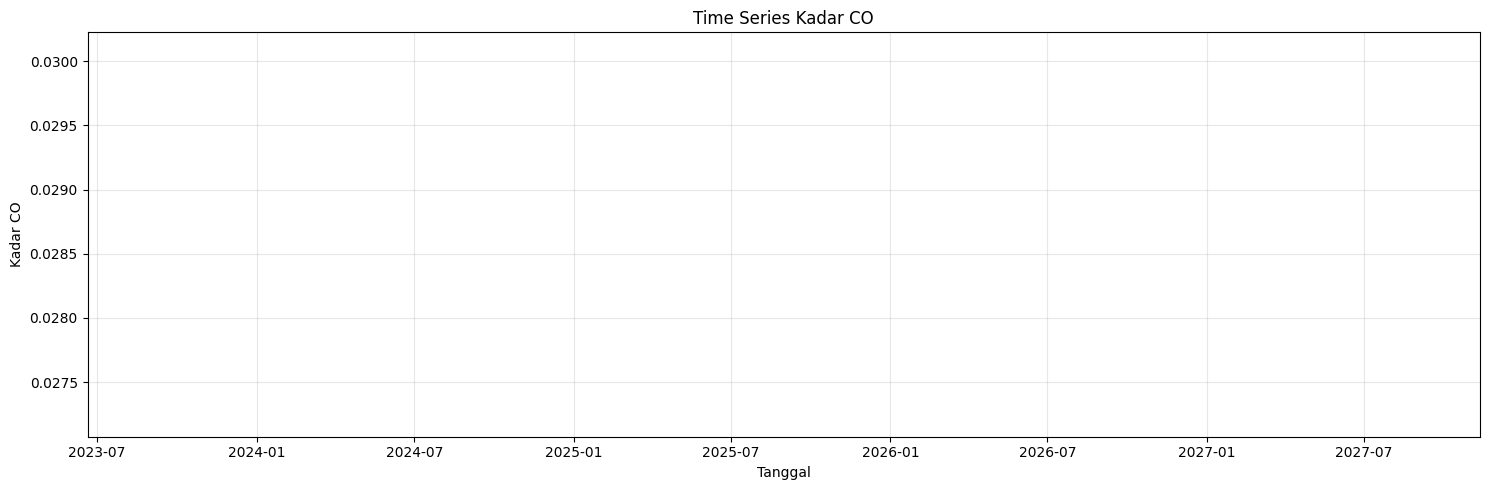

In [32]:
plot_time_series(
    df_co,
    "CO"
)

## 22. Grafik NO₂

Time Series NO₂ Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai NO₂ harian selama periode penelitian. Pola naik dan turun pada grafik dapat digunakan untuk melihat perubahan konsentrasi NO₂ dari waktu ke waktu.


Jumlah data yang diplot: 283
Tanggal awal: 2025-08-31 00:00:00
Tanggal akhir: 2026-08-30 00:00:00


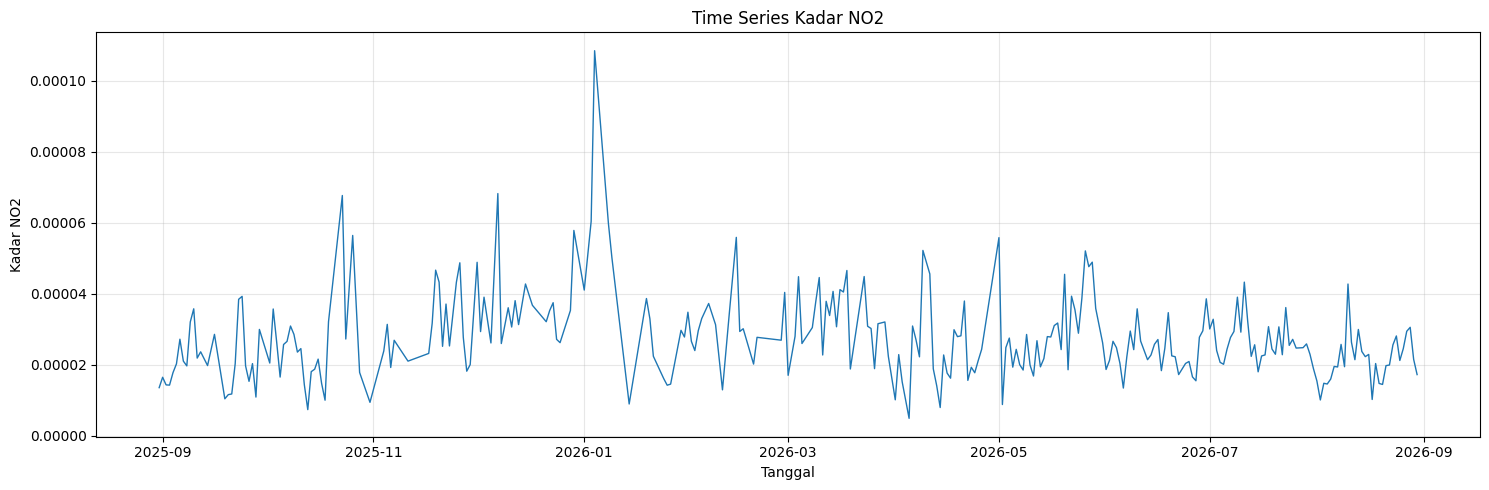

In [33]:
plot_time_series(
    no2_df,
    "NO2"
)

## 23. Grafik HCHO
Time Series HCHO Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai HCHO selama periode pengamatan dan digunakan untuk melihat pola fluktuasi HCHO berdasarkan waktu.


Jumlah data yang diplot: 325
Tanggal awal: 2025-08-31 00:00:00
Tanggal akhir: 2026-08-30 00:00:00


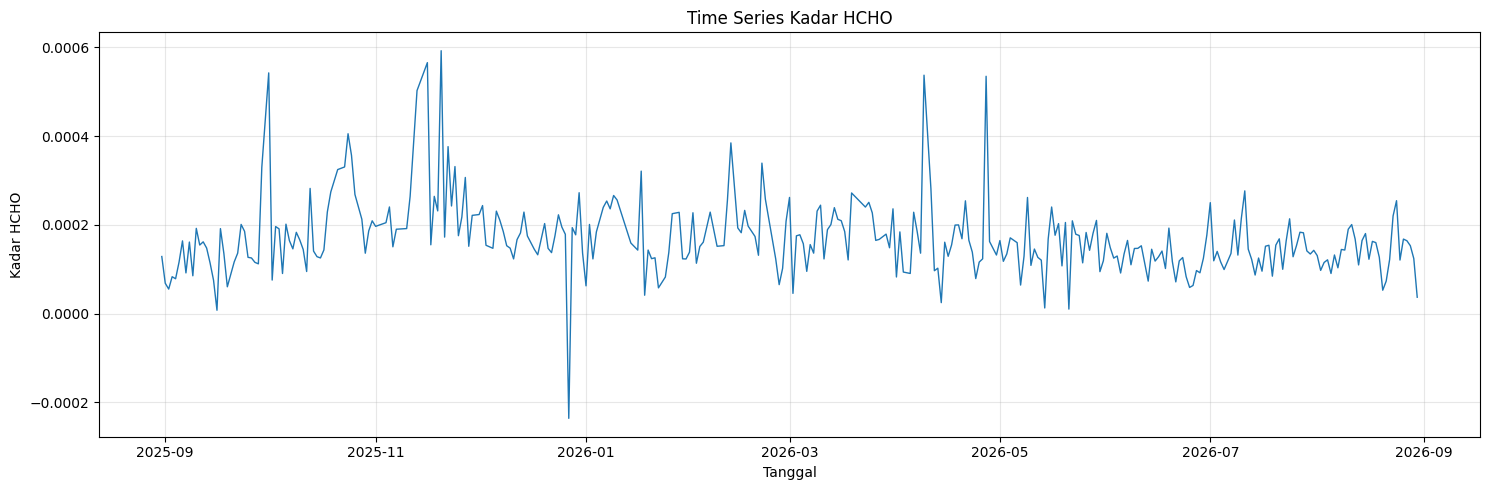

In [34]:
plot_time_series(
    hcho_df,
    "HCHO"
)

## 24. Grafik O₃

Time Series O₃ Kabupaten Bangkalan

Grafik digunakan untuk melihat perubahan nilai O₃ dari waktu ke waktu selama periode penelitian dan mengidentifikasi pola fluktuasinya.


Jumlah data yang diplot: 361
Tanggal awal: 2025-08-31 00:00:00
Tanggal akhir: 2026-08-30 00:00:00


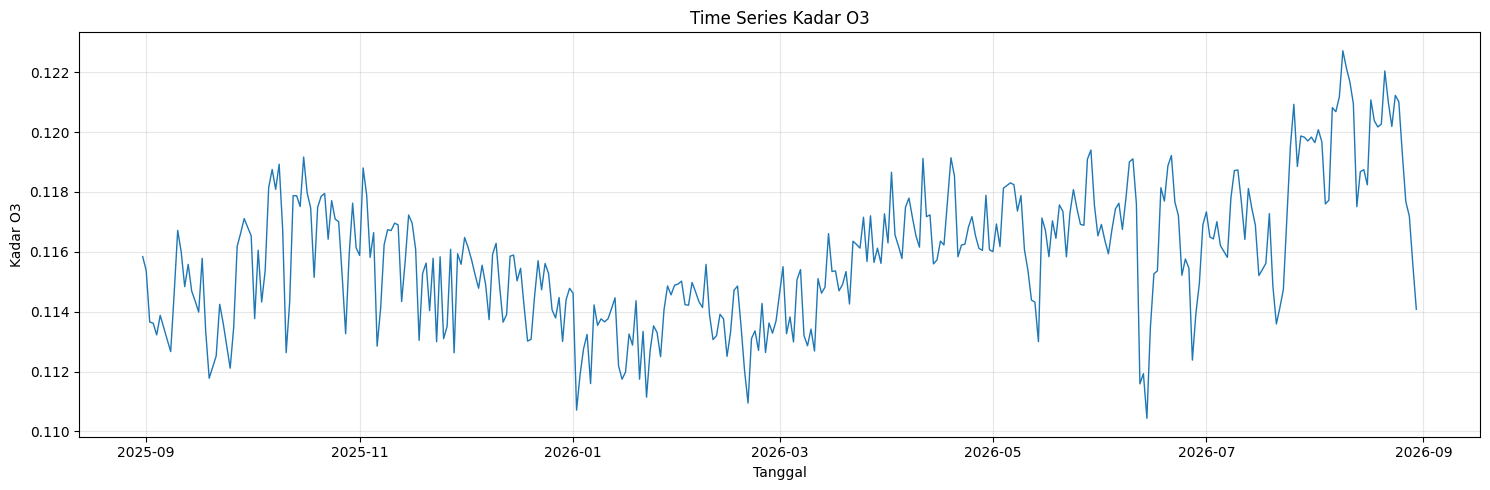

In [35]:
plot_time_series(
    o3_df,
    "O3"
)

## 25. Grafik SO₂

Time Series SO₂ Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai SO₂ selama periode pengamatan sehingga dapat diamati pola naik-turun nilai SO₂ dari waktu ke waktu.


Jumlah data yang diplot: 316
Tanggal awal: 2025-08-31 00:00:00
Tanggal akhir: 2026-08-30 00:00:00


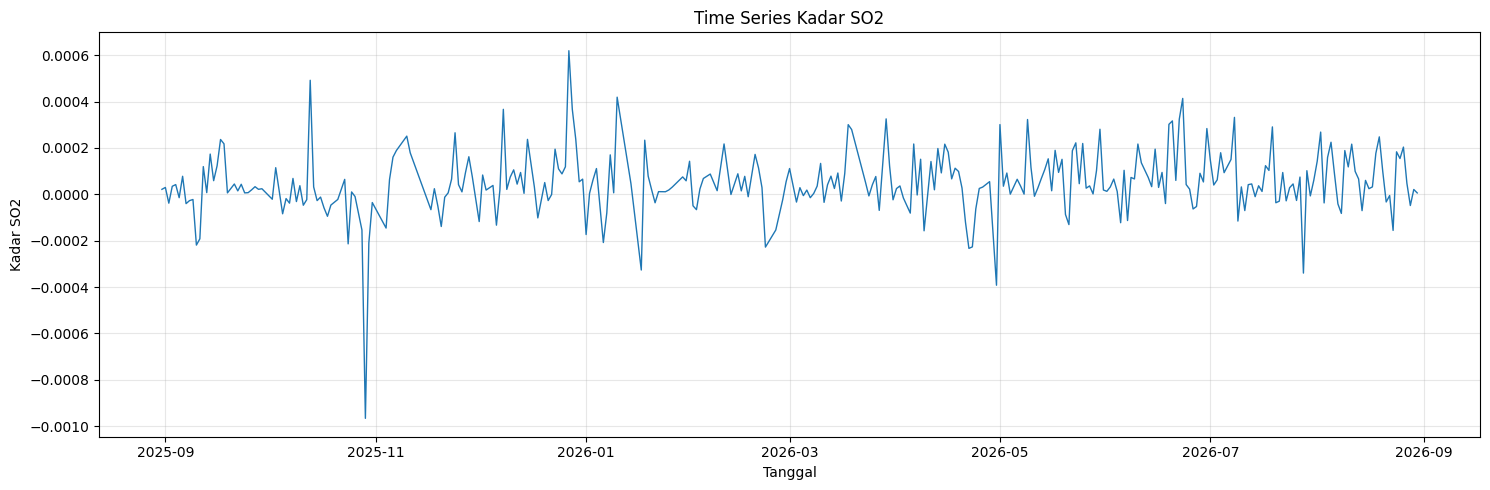

In [36]:
plot_time_series(
    so2_df,
    "SO2"
)

## 26. Grafik CH₄

Time Series CH₄ Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai CH₄ selama periode penelitian dan digunakan untuk mengamati pola serta fluktuasi nilai CH₄ berdasarkan waktu.


Jumlah data yang diplot: 83
Tanggal awal: 2025-09-02 00:00:00
Tanggal akhir: 2026-08-30 00:00:00


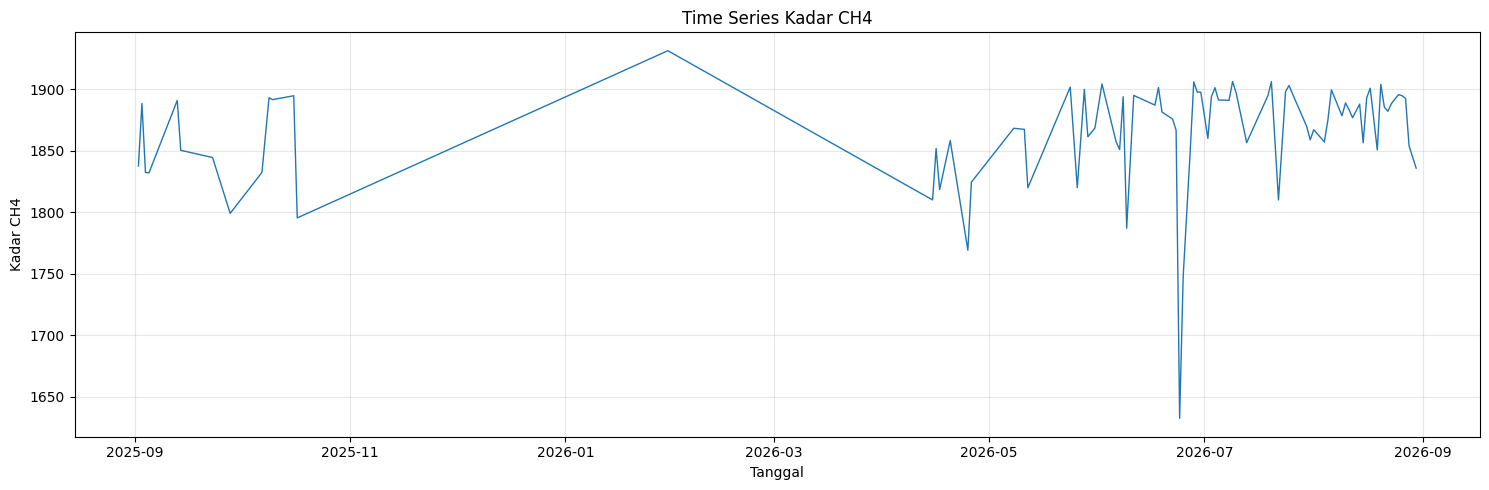

In [37]:
plot_time_series(
    ch4_df,
    "CH4"
)

## 27. Grafik outlier


Deteksi outlier dilakukan untuk mengetahui apakah terdapat nilai polutan yang memiliki perbedaan cukup jauh dibandingkan sebagian besar data.

Metode yang digunakan adalah **IQR (Interquartile Range)**. Batas bawah dan batas atas dihitung berdasarkan kuartil pertama (Q1), kuartil ketiga (Q3), dan nilai IQR.

Nilai yang berada di luar batas tersebut ditandai sebagai kemungkinan outlier. Outlier tidak langsung dianggap sebagai kesalahan data karena dapat menunjukkan adanya perubahan atau kondisi tertentu pada waktu pengamatan.

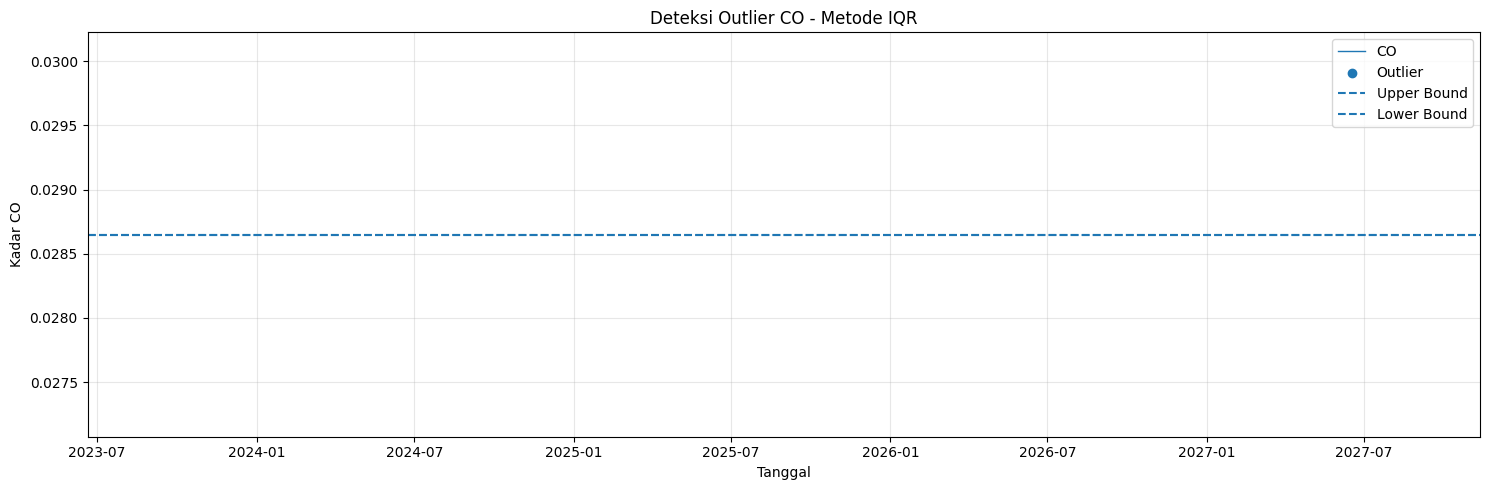

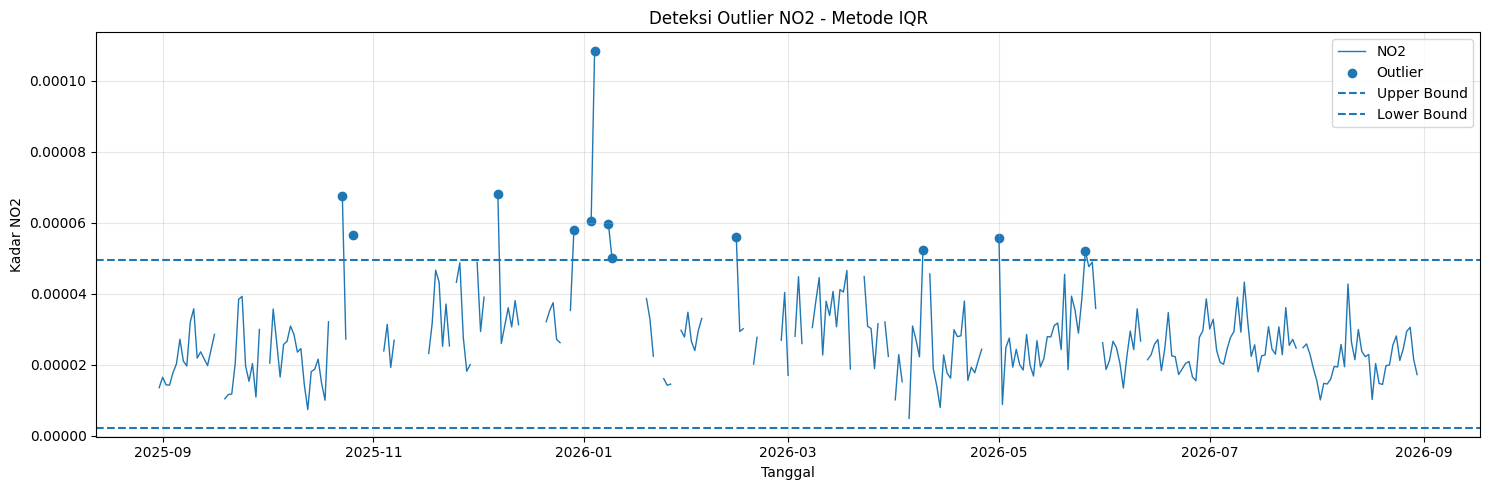

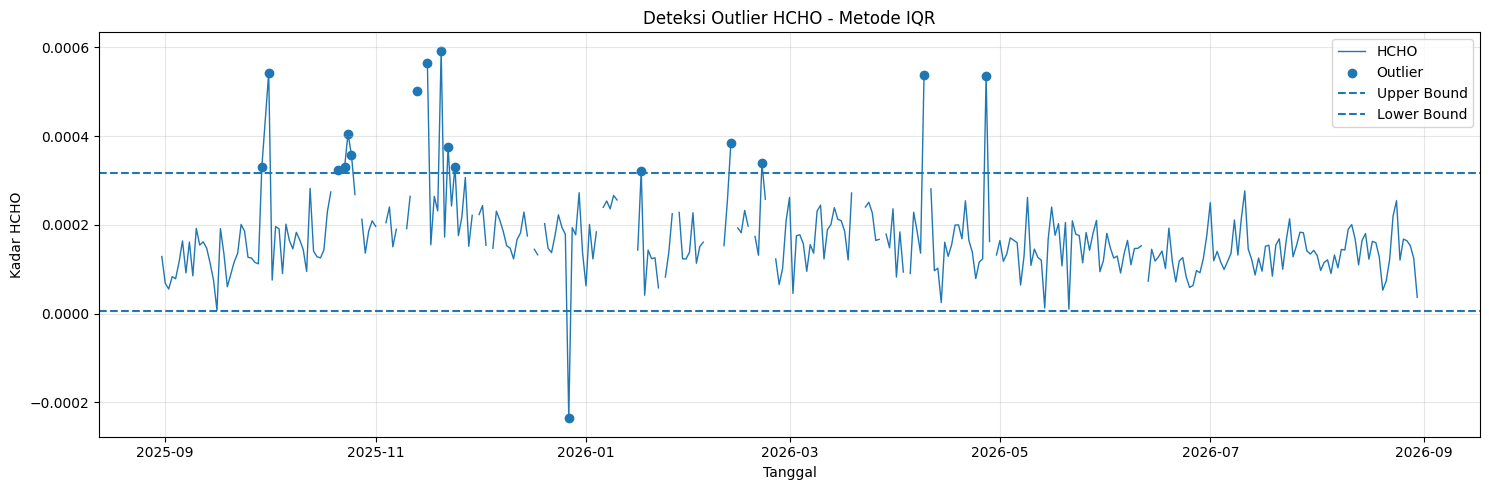

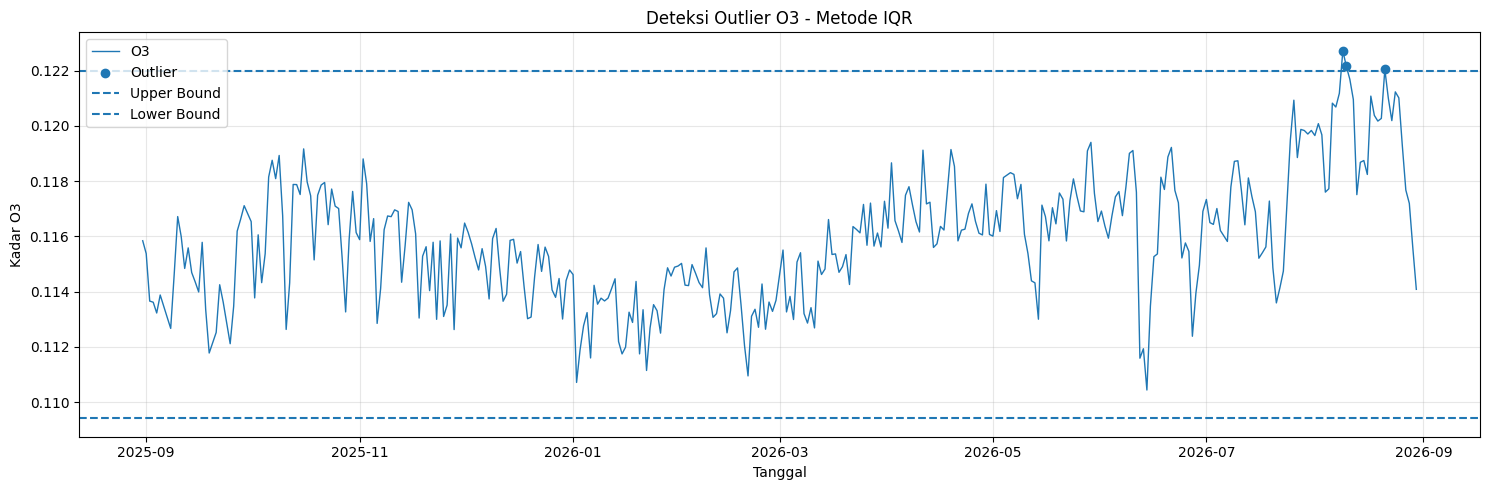

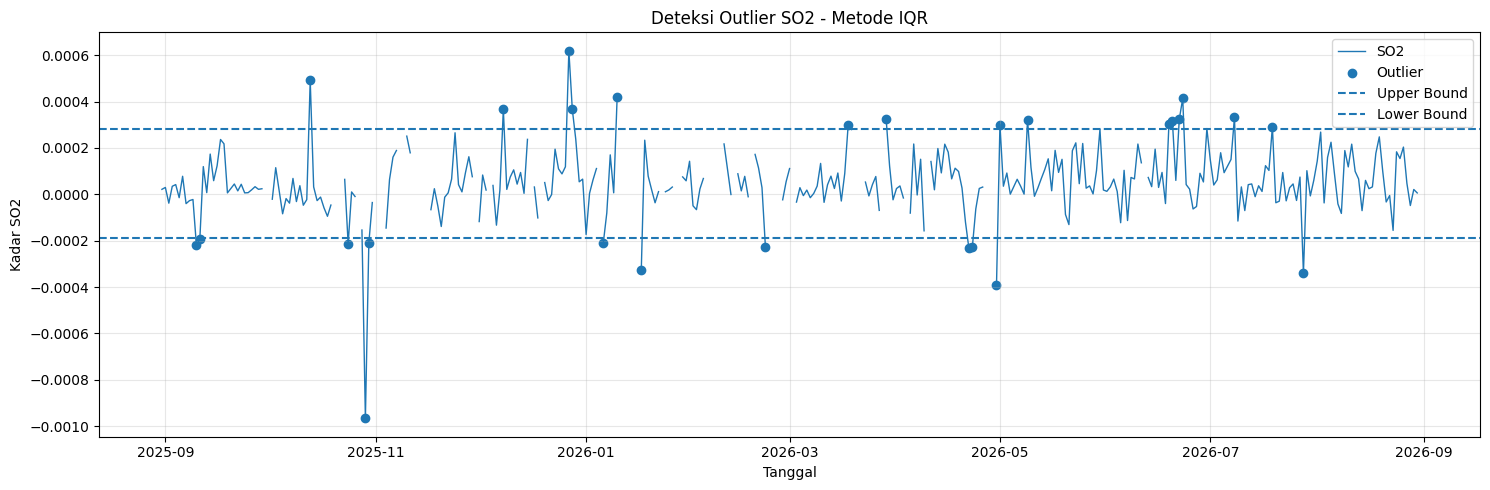

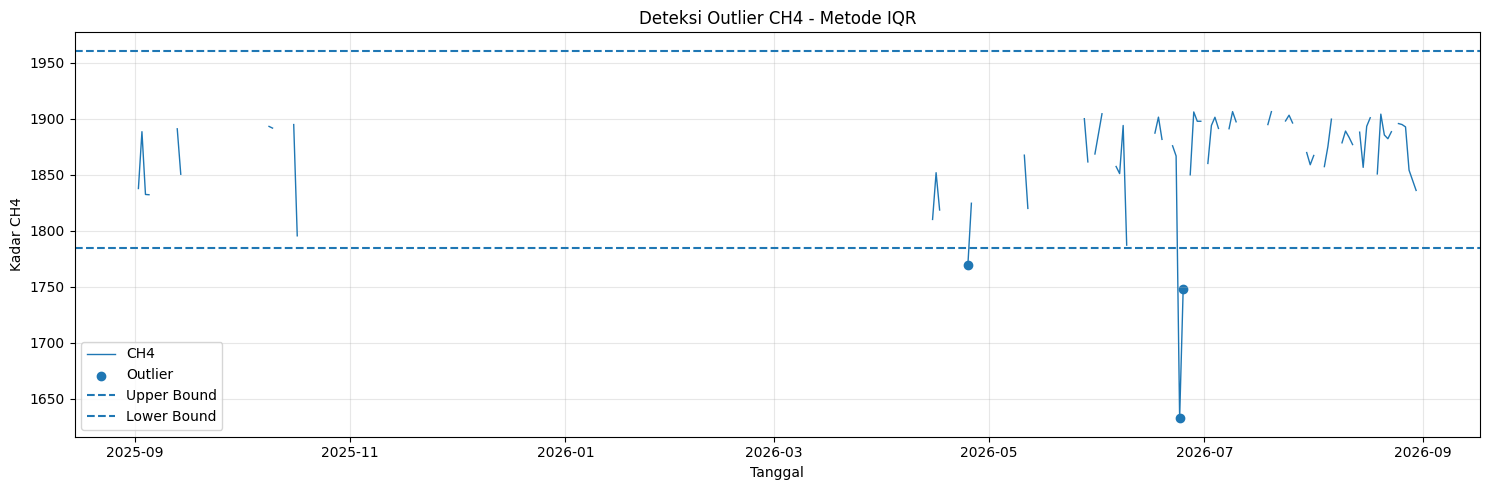

In [38]:
def plot_outliers(
    df,
    outliers,
    variable_name,
    lower_bound,
    upper_bound
):

    plt.figure(figsize=(15, 5))

    plt.plot(
        df["date"],
        df[variable_name],
        linewidth=1,
        label=variable_name
    )

    plt.scatter(
        outliers["date"],
        outliers[variable_name],
        marker="o",
        label="Outlier"
    )

    plt.axhline(
        upper_bound,
        linestyle="dashed",
        label="Upper Bound"
    )

    plt.axhline(
        lower_bound,
        linestyle="dashed",
        label="Lower Bound"
    )

    plt.title(
        f"Deteksi Outlier {variable_name} - Metode IQR"
    )

    plt.xlabel("Tanggal")
    plt.ylabel(
        f"Kadar {variable_name}"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_outliers(co_df, co_outliers, "CO", co_lower, co_upper)
plot_outliers(no2_df, no2_outliers, "NO2", no2_lower, no2_upper)
plot_outliers(hcho_df, hcho_outliers, "HCHO", hcho_lower, hcho_upper)
plot_outliers(o3_df, o3_outliers, "O3", o3_lower, o3_upper)
plot_outliers(so2_df, so2_outliers, "SO2", so2_lower, so2_upper)
plot_outliers(ch4_df, ch4_outliers, "CH4", ch4_lower, ch4_upper)

## 28. Tabel Ringkasan Data

Tabel ringkasan digunakan untuk membandingkan karakteristik seluruh polutan yang dianalisis di Kabupaten Bangkalan.

Informasi yang ditampilkan meliputi jumlah data, missing value, nilai minimum, maksimum, rata-rata, median, dan jumlah outlier.

Tabel ini membantu memberikan gambaran umum mengenai kondisi dataset sebelum dilakukan interpretasi lebih lanjut.


In [39]:
summary = []

for file_path, variable in [
    ("CO_timeseries.csv", "CO"),
    ("NO2_timeseries.csv", "NO2"),
    ("HCHO_timeseries.csv", "HCHO"),
    ("O3_timeseries.csv", "O3"),
    ("SO2_timeseries.csv", "SO2"),
    ("CH4_timeseries.csv", "CH4")
]:

    df = pd.read_csv(file_path)

    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = (
        (df[variable] < lower) |
        (df[variable] > upper)
    ).sum()

    summary.append({
        "Polutan": variable,
        "Jumlah Data": len(df),
        "Missing Value": df[variable].isna().sum(),
        "Minimum": df[variable].min(),
        "Maximum": df[variable].max(),
        "Mean": df[variable].mean(),
        "Median": df[variable].median(),
        "Outlier": outlier_count
    })

summary_df = pd.DataFrame(summary)

summary_df

,Polutan,Jumlah Data,Missing Value,Minimum,Maximum,Mean,Median,Outlier
0,CO,1,0,0.028650,0.028650,0.028650,0.028650,0
1,NO2,363,80,0.000005,0.000109,0.000027,0.000026,12
2,HCHO,361,36,-0.000236,0.000593,0.000169,0.000154,17
3,O3,361,0,0.110438,0.122721,0.115844,0.115816,3
4,SO2,361,45,-0.000966,0.000619,0.000050,0.000036,27
5,CH4,214,131,1632.623400,1931.454600,1866.006376,1878.554100,3
